## Import Important Libraries

In [1]:
!python --version

Python 3.12.13


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

## Download Stopwords

In [3]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Load the Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


## Remove Duplicates

In [6]:
df.drop_duplicates(inplace=True)

## sentiment distribution calculation

In [7]:
sentimentCounts = df['sentiment'].value_counts()
sentimentLabels = sentimentCounts.index
sentimentSizes = sentimentCounts.values

## Sentiment distribution pie chart

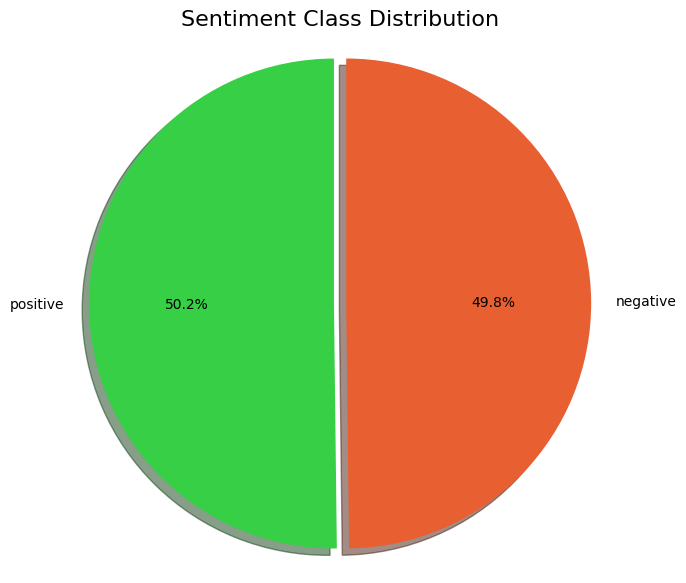

In [31]:
plt.figure(figsize=(7, 7))
plt.pie(sentimentSizes, labels=sentimentLabels, autopct='%1.1f%%', startangle=90, colors=['#36cf45', '#e85f31'], explode=(0.05, 0), shadow=True)
plt.title('Sentiment Class Distribution', fontsize=16)
plt.axis('equal')
plt.show()


In [9]:
print("Total rows:", len(df))
print(df['sentiment'].value_counts())

Total rows: 49582
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


## Text Preprocessing

In [10]:
stopWords = set(stopwords.words('english'))
negationWords = {'not', 'no', 'never', 'nor', 'neither', "n't"}
stopWords -= negationWords

ps = PorterStemmer()

def preprocessedText(text):
    text = text.lower()
    text = re.sub('<br />', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = word_tokenize(text)
    words = [ps.stem(word) for word in words if word not in stopWords]
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(preprocessedText)

df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one review mention watch 1 oz episod youll hoo...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


## Visualization of Frequent Words Before and After Preprocessing

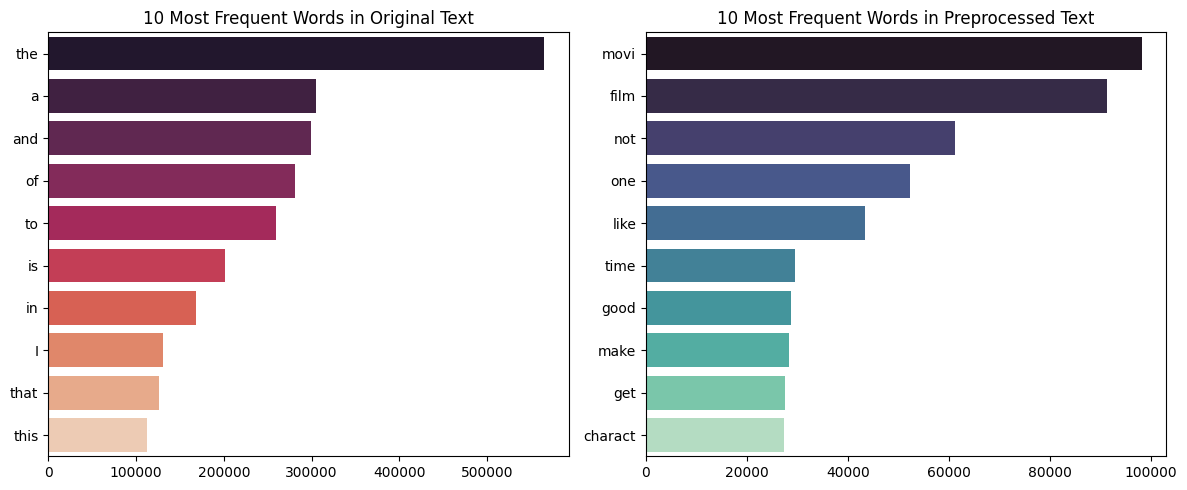

In [11]:
from collections import Counter

def getWordFreqs(textColumn):
    words = []
    for review in textColumn:
        words.extend(review.split())
    return Counter(words)

#---------------word frequencies for original and cleaned reviews
originalWordFreqs = getWordFreqs(df['review'])
preprocessedWordFreqs = getWordFreqs(df['cleaned_review'])

#----------top 10 frequent words
originalCommonWords = originalWordFreqs.most_common(10)
preprocessedCommonWords = preprocessedWordFreqs.most_common(10)

originalWords = [word for word, count in originalCommonWords]
originalWordCounts = [count for word, count in originalCommonWords]

preprocessedWords = [word for word, count in preprocessedCommonWords]
preprocessedWordCounts = [count for word, count in preprocessedCommonWords]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=originalWordCounts, y=originalWords, hue=originalWords, palette='rocket', legend=False)
plt.title('10 Most Frequent Words in Original Text')

plt.subplot(1, 2, 2)
sns.barplot(x=preprocessedWordCounts, y=preprocessedWords, hue=preprocessedWords, palette='mako', legend=False)
plt.title('10 Most Frequent Words in Preprocessed Text')
plt.tight_layout()
plt.show()

## Word Clouds

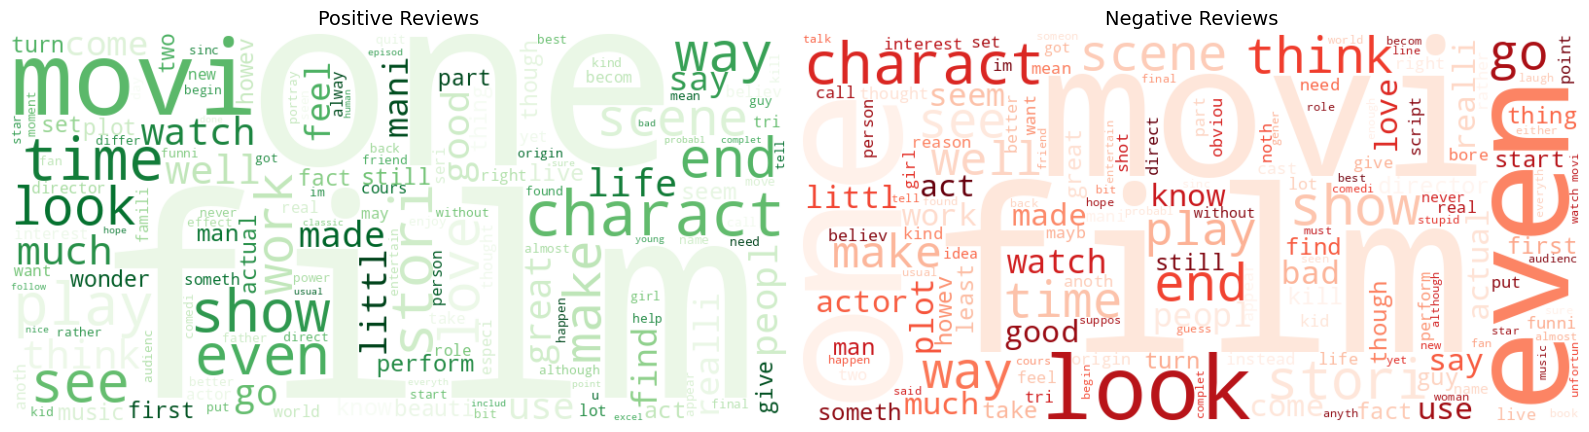

In [12]:
from wordcloud import WordCloud

positiveText = ' '.join(df.loc[df['sentiment'] == 'positive', 'cleaned_review'])
negativeText = ' '.join(df.loc[df['sentiment'] == 'negative', 'cleaned_review'])

positiveWC = WordCloud(width=800, height=400, background_color='white',
                         colormap='Greens', max_words=150, random_state=42).generate(positiveText)
negativeWC = WordCloud(width=800, height=400, background_color='white',
                         colormap='Reds', max_words=150, random_state=42).generate(negativeText)

#---plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(positiveWC, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14)
axes[0].axis('off')

axes[1].imshow(negativeWC, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## Applying TF-IDF vectorization

In [14]:
vectorizer = TfidfVectorizer(max_features = 7000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['cleaned_review']).toarray()
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"shape of taining set: {X_train.shape} and test set: {X_test.shape}")

shape of taining set: (39665, 7000) and test set: (9917, 7000)


## Import different evaluation metrics

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
model_results={}
def record_results(model, y_true, y_pred):
    model_results[model] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

## Logistic Regression

In [16]:
model_logistic = LogisticRegression(max_iter=100)
model_logistic.fit(X_train, y_train)
y_pred_model_logistic = model_logistic.predict(X_test)

print(f"Classification Report of Logistic regression:\n{classification_report(y_test, y_pred_model_logistic)}")

Classification Report of Logistic regression:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4939
           1       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [17]:
print(model_logistic.classes_)

[0 1]


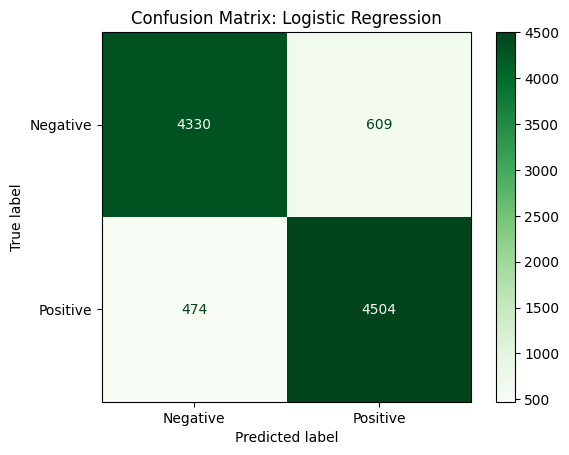

In [18]:
cm_model_logistic = confusion_matrix(y_test, y_pred_model_logistic)
ConfusionMatrixDisplay(cm_model_logistic, display_labels=['Negative', 'Positive']).plot(cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

In [19]:
record_results('Logistic Regression', y_test, y_pred_model_logistic)

## Naive Bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB
model_naive = MultinomialNB()
model_naive.fit(X_train, y_train)
y_pred_model_naive = model_naive.predict(X_test)
print(f"Classification Report of Naive Bayes:\n{classification_report(y_test, y_pred_model_naive)}")

Classification Report of Naive Bayes:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4939
           1       0.85      0.88      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



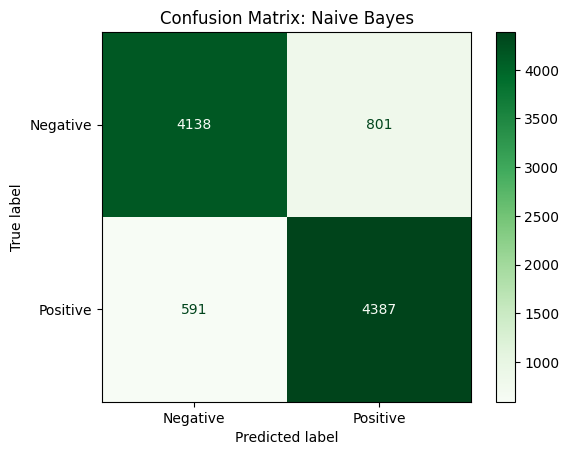

In [21]:
cm_model_naive = confusion_matrix(y_test, y_pred_model_naive)
ConfusionMatrixDisplay(cm_model_naive, display_labels=['Negative', 'Positive']).plot(cmap='Greens')
plt.title('Confusion Matrix: Naive Bayes')
plt.show()


In [22]:
record_results('Naive Bayes', y_test, y_pred_model_naive)

## LightGBM

In [23]:
from lightgbm import LGBMClassifier
model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train, y_train)
y_pred_model_lgbm = model_lgbm.predict(X_test)

print(f"Classification Report of LightGBM:\n{classification_report(y_test, y_pred_model_lgbm)}")

[LightGBM] [Info] Number of positive: 19906, number of negative: 19759
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.391981 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 693601
[LightGBM] [Info] Number of data points in the train set: 39665, number of used features: 6999
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501853 -> initscore=0.007412
[LightGBM] [Info] Start training from score 0.007412
Classification Report of LightGBM:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4939
           1       0.84      0.87      0.86      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


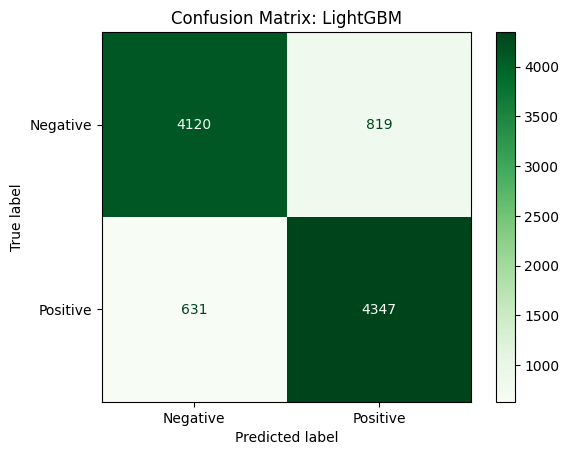

In [24]:
cm_model_lgbm = confusion_matrix(y_test, y_pred_model_lgbm)
ConfusionMatrixDisplay(cm_model_lgbm, display_labels=['Negative', 'Positive']).plot(cmap='Greens')
plt.title('Confusion Matrix: LightGBM')
plt.show()

In [25]:
record_results('LightGBM', y_test, y_pred_model_lgbm)

## 3 Models Comparision

In [26]:
results_df = pd.DataFrame(model_results).T
print(results_df)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.890794   0.880892  0.904781  0.892677
Naive Bayes          0.859635   0.845605  0.881278  0.863073
LightGBM             0.853786   0.841463  0.873242  0.857058


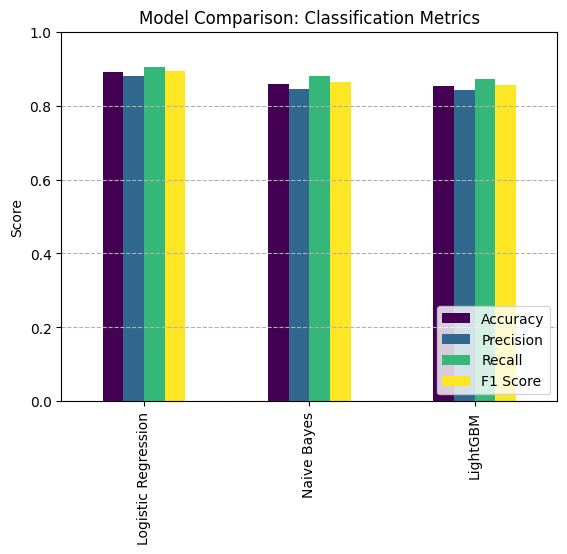

In [32]:
results_df.plot(kind='bar', colormap='viridis')
plt.title('Model Comparison: Classification Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=1)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


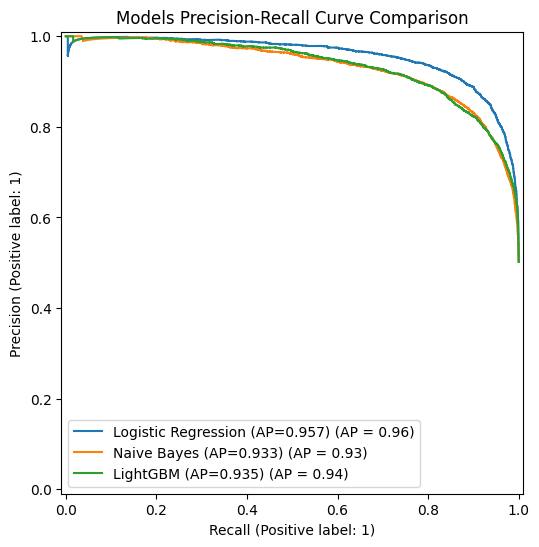

In [28]:
y_scores_model_logistic = model_logistic.predict_proba(X_test)[:, 1]
y_scores_model_naive = model_naive.predict_proba(X_test)[:, 1]
y_scores_model_lgbm = model_lgbm.predict_proba(X_test)[:, 1]

model_scores = {
    'Logistic Regression': y_scores_model_logistic,
    'Naive Bayes': y_scores_model_naive,
    'LightGBM': y_scores_model_lgbm
}

from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
fig, ax = plt.subplots(figsize=(8, 6))
for name, scores in model_scores.items():
    ap = average_precision_score(y_test, scores)
    PrecisionRecallDisplay.from_predictions(y_test, scores, name=f'{name} (AP={ap:.3f})', ax=ax)
plt.title('Models Precision-Recall Curve Comparison')
plt.show()

## saving the vectorizer and model for the future purpose

In [29]:
import joblib

joblib.dump(model_logistic, 'model_logistic.pkl')
joblib.dump(model_naive, 'model_naive.pkl')
joblib.dump(model_lgbm, 'model_lgbm.pkl')
joblib.dump(vectorizer, 'vectorizer_vectorizer.pkl')

['vectorizer_vectorizer.pkl']

## prediction interface for users

In [ ]:
import ipywidgets as widgets